# Rastreador de Preços — GPUs e PS5

Este notebook coleta, armazena e analisa o histórico de preços de placas de
vídeo e consoles:

- **AMD RX 9070 XT 16GB** — ASRock Challenger
- **NVIDIA RTX 5070 Ti 16GB** — MSI Shadow 3X OC
- **NVIDIA RTX 5070 12GB** — menor preço por loja (PNY OC na Promotech, MSI
  Ventus 2X OC na Kabum, Palit White OC na Terabyte — ver nota abaixo)
- **Sony PlayStation 5 Edição Digital 825GB** — menor preço entre lojas via
  Buscapé
- **Sony PlayStation 5 Slim 1TB** — menor preço entre lojas via Buscapé

Objetivo: entender o comportamento do mercado (quando o preço sobe, quando
desce, sazonalidade) para identificar um bom momento de compra.

**Como usar:**
1. Rode a célula de coleta periodicamente (ex.: uma vez por dia) — cada
   execução adiciona uma linha nova em `data/historico_precos.csv`, sem
   apagar o que já foi coletado.
2. Rode as células de análise sempre que quiser ver o estado atual.
3. Quanto mais tempo você deixar isso rodando, mais confiável fica a análise
   de média móvel e sazonalidade — com poucos pontos, os gráficos vão
   aparecer, mas os padrões ainda não serão estatisticamente sólidos.

**Sobre a coleta:** os preços das GPUs são obtidos via scraping direto de
Kabum e Terabyte (dados estruturados JSON-LD) e via Promotech (comparador de
preços — usa a página de busca, que já vem com o preço em texto simples, e
retorna o menor preço encontrado entre as lojas que ele compara). O PS5 é
obtido via Buscapé (outro comparador de preços), cuja própria página de
produto já expõe o menor preço agregado em JSON-LD, sem precisar de página
de busca. O notebook já vem com um ponto inicial de dados extraído
manualmente do [Promotech](https://promotech.app.br) para cada modelo de
GPU. A Pichau não está entre as lojas ativas: o site bloqueia scraping com
um desafio Cloudflare (HTTP 403), então não há preço para extrair dali — se
quiser acompanhá-la, precisa conferir manualmente. Se algum dos outros
sites mudar de layout, o scraper daquela loja pode parar de retornar preço
— isso é normal nesse tipo de ferramenta, veja a seção "Solução de
problemas" no fim do notebook.

**Sobre a RTX 5070 12GB:** diferente das outras duas linhas de GPU, aqui
cada loja aponta para um modelo/fabricante diferente (não existe uma SKU
única sendo comparada entre lojas) — o que é acompanhado é o menor preço de
uma RTX 5070 12GB disponível em cada loja, não um cooler/fabricante fixo.
Se preferir travar numa SKU específica por loja, edite `PRODUTOS_MODELOS`
em `config.py`.

**Sobre o PS5:** Edição Digital e Slim 1TB são acompanhados como modelos
separados (preços bem diferentes, não fazem sentido combinados). Cada um
usa uma única URL do Buscapé, então "loja" aqui sempre aparece como
"Buscapé (menor preço)" — é o comparador que já faz o trabalho de achar o
menor preço entre os vendedores que ele lista para aquele anúncio.


In [1]:
import sys
from pathlib import Path
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
from IPython.display import display

sys.path.append(str(Path.cwd()))
import config
import scrapers
import cotacao_dolar

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CSV_HISTORICO = Path(config.CSV_HISTORICO)
CSV_DOLAR = Path(config.CSV_DOLAR)
print("Ambiente carregado.")


Ambiente carregado.


## 1. Coletar preços agora

Rode esta célula sempre que quiser adicionar um novo ponto ao histórico. Ela não apaga nada — só acrescenta linhas novas ao CSV.

In [2]:
# debug=True salva o HTML bruto em data/debug_html/ quando um scraper falha
# em achar o preço — útil para ajustar a extração se um site mudar o layout.
novos_registros = scrapers.coletar_todos(config.PRODUTOS_MODELOS, debug=True)

if novos_registros:
    df_novos = pd.DataFrame(novos_registros)
    cabecalho = not CSV_HISTORICO.exists()
    df_novos.to_csv(CSV_HISTORICO, mode="a", header=cabecalho, index=False)
    print(f"\n{len(novos_registros)} novo(s) registro(s) salvo(s) em {CSV_HISTORICO}")
else:
    print("Nenhum preço novo coletado nesta execução (veja mensagens de erro acima).")


[OK] RX 9070 XT 16GB — Kabum: R$ 4999.99
[OK] RX 9070 XT 16GB — Terabyte: R$ 5099.90
[OK] RX 9070 XT 16GB — Promotech (menor preço): R$ 4899.89
[OK] RTX 5070 Ti 16GB — Kabum: R$ 7649.91
[OK] RTX 5070 Ti 16GB — Terabyte: R$ 8549.91
[OK] RTX 5070 Ti 16GB — Promotech (menor preço): R$ 7083.08
[OK] RTX 5070 12GB — Kabum: R$ 4999.99
[OK] RTX 5070 12GB — Terabyte: R$ 4899.90
[OK] RTX 5070 12GB — Promotech (menor preço): R$ 4699.99
[OK] PS5 Edição Digital 825GB — Buscapé (menor preço): R$ 4231.91
[OK] PS5 Slim 1TB — Buscapé (menor preço): R$ 4299.90

11 novo(s) registro(s) salvo(s) em data\historico_precos.csv


## 2. Cotação do dólar (USD/BRL)

GPU no Brasil é majoritariamente importada, então o câmbio costuma explicar parte da variação de preço. Isso já traz histórico de até um ano, então não precisamos esperar semanas para ter esse dado.

In [3]:
try:
    df_dolar = cotacao_dolar.obter_historico_dolar(dias=365)
    df_dolar.to_csv(CSV_DOLAR, index=False)
    print(f"{len(df_dolar)} cotações diárias carregadas.")
    display(df_dolar.tail())
except Exception as e:
    print(f"Não foi possível obter a cotação do dólar agora: {e}")
    print("Sem problema — rode esta célula de novo mais tarde. A Seção 8 (preço x dólar) "
          "vai avisar e pular automaticamente até que exista data/cotacao_dolar.csv.")


360 cotações diárias carregadas.


,data,cotacao_venda
355,2026-08-21,5.1380
356,2026-08-23,5.1364
357,2026-08-24,5.1572
358,2026-08-25,5.1472
359,2026-08-26,5.1585


## 3. Carregar o histórico de preços

In [4]:
df = pd.read_csv(CSV_HISTORICO, parse_dates=["data_hora"])
df["data"] = df["data_hora"].dt.date
df = df.sort_values("data_hora").reset_index(drop=True)

print(f"{len(df)} registros no total, de {df['data_hora'].min()} até {df['data_hora'].max()}")
df.tail(10)


130 registros no total, de 2026-08-13 00:00:00 até 2026-08-26 13:41:15


,data_hora,loja,modelo,preco,titulo_produto,url,data
120,2026-08-26 13:40:35,Terabyte,RX 9070 XT 16GB,5099.90,Placa de Vídeo ASRock RX 9070 XT Challenger 16...,https://www.terabyteshop.com.br/produto/38584/...,2026-08-26
121,2026-08-26 13:40:39,Promotech (menor preço),RX 9070 XT 16GB,4899.89,"ASRock RX 9070 XT Challenger R$ 4.899,89 ou R$...",https://promotech.app.br/busca?q=Rx+9070+XT,2026-08-26
122,2026-08-26 13:40:43,Kabum,RTX 5070 Ti 16GB,7649.91,Placa De Video Msi Geforce RTX 5070 Ti Shadow ...,https://www.kabum.com.br/produto/779497/placa-...,2026-08-26
123,2026-08-26 13:40:48,Terabyte,RTX 5070 Ti 16GB,8549.91,GPU MSI RTX 5070 Ti Shadow 3X OC 16GB GDDR7 | ...,https://www.terabyteshop.com.br/produto/35475/...,2026-08-26
124,2026-08-26 13:40:53,Promotech (menor preço),RTX 5070 Ti 16GB,7083.08,"MSI RTX 5070 Ti Shadow 3X OC R$ 7.083,08 ou R$...",https://promotech.app.br/busca?q=RTX+5070+TI,2026-08-26
125,2026-08-26 13:40:59,Kabum,RTX 5070 12GB,4999.99,Placa de Vídeo MSI GeForce RTX 5070 12G VENTUS...,https://www.kabum.com.br/produto/725587/placa-...,2026-08-26
126,2026-08-26 13:41:03,Terabyte,RTX 5070 12GB,4899.90,Placa de Vídeo Palit RTX 5070 White OC 12GB GD...,https://www.terabyteshop.com.br/produto/40135/...,2026-08-26
127,2026-08-26 13:41:06,Promotech (menor preço),RTX 5070 12GB,4699.99,"PNY RTX 5070 OC R$ 4.699,99 ou R$ 5.529,36 par...",https://promotech.app.br/busca?q=RTX+5070,2026-08-26
128,2026-08-26 13:41:10,Buscapé (menor preço),PS5 Edição Digital 825GB,4231.91,PlayStation 5 Edição Digital 825GB,https://www.buscape.com.br/console-de-video-ga...,2026-08-26
129,2026-08-26 13:41:15,Buscapé (menor preço),PS5 Slim 1TB,4299.90,Playstation 5 Slim Edição Digital 1TB,https://www.buscape.com.br/console-de-video-ga...,2026-08-26


## 4. Série de preços por modelo (bruto + média móvel)

A média móvel só aparece quando já existem pontos suficientes — com poucos dias de coleta, o gráfico mostra só os preços brutos.

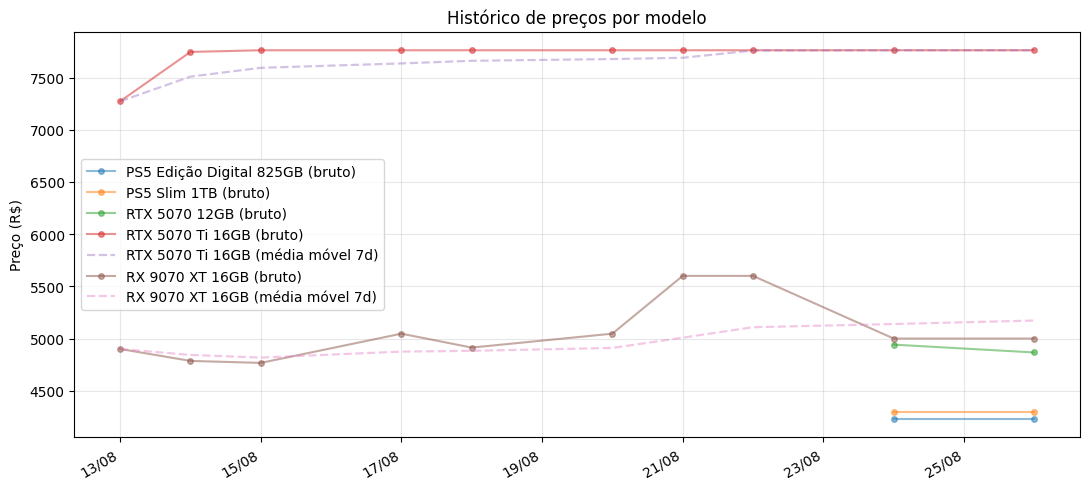

In [5]:
JANELA_MEDIA_MOVEL = 7  # dias

fig, ax = plt.subplots()

for modelo, grupo in df.groupby("modelo"):
    diario = grupo.groupby("data")["preco"].mean().reset_index()
    diario["data"] = pd.to_datetime(diario["data"])
    ax.plot(diario["data"], diario["preco"], marker="o", markersize=4, label=f"{modelo} (bruto)", alpha=0.5)

    if len(diario) >= JANELA_MEDIA_MOVEL:
        diario["media_movel"] = diario["preco"].rolling(JANELA_MEDIA_MOVEL, min_periods=1).mean()
        ax.plot(diario["data"], diario["media_movel"], linewidth=1.6, linestyle="--", alpha = 0.4, label=f"{modelo} (média móvel {JANELA_MEDIA_MOVEL}d)")

ax.set_title("Histórico de preços por modelo")
ax.set_ylabel("Preço (R$)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
fig.autofmt_xdate()
ax.legend()
plt.tight_layout()
plt.show()


## 5. Comparativo entre os modelos

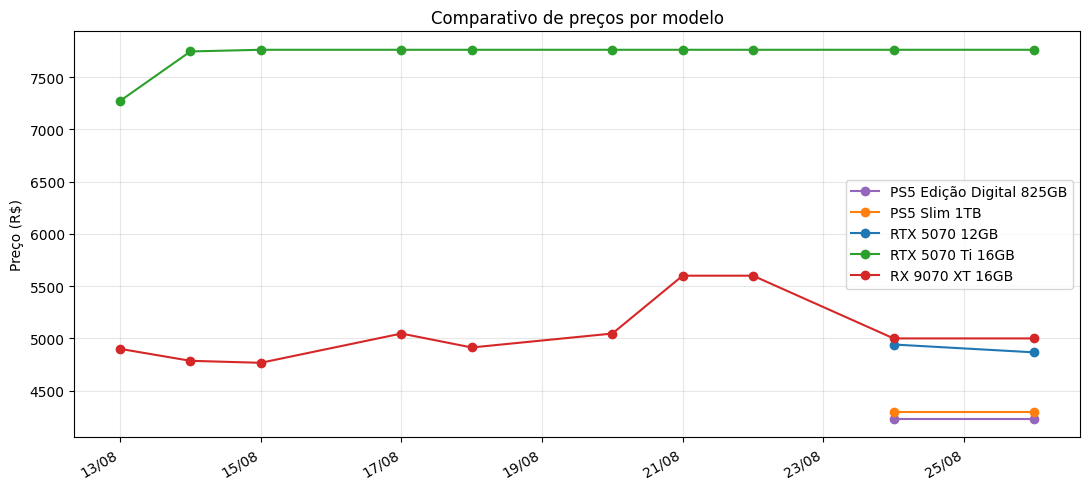

In [6]:
fig, ax = plt.subplots()
cores = {
    "RX 9070 XT 16GB": "tab:red",
    "RTX 5070 Ti 16GB": "tab:green",
    "RTX 5070 12GB": "tab:blue",
    "PS5 Edição Digital 825GB": "tab:purple",
    "PS5 Slim 1TB": "tab:orange",
}

for modelo, grupo in df.groupby("modelo"):
    diario = grupo.groupby("data")["preco"].mean().reset_index()
    diario["data"] = pd.to_datetime(diario["data"])
    ax.plot(diario["data"], diario["preco"], marker="o", label=modelo, color=cores.get(modelo))

ax.set_title("Comparativo de preços por modelo")
ax.set_ylabel("Preço (R$)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
fig.autofmt_xdate()
ax.legend()
plt.tight_layout()
plt.show()


## 6. Estatísticas resumo por modelo

In [7]:
linhas_resumo = []
for modelo, grupo in df.groupby("modelo"):
    atual = grupo.sort_values("data_hora")["preco"].iloc[-1]
    linhas_resumo.append({
        "modelo": modelo,
        "preco_atual": atual,
        "preco_minimo": grupo["preco"].min(),
        "preco_maximo": grupo["preco"].max(),
        "preco_medio": grupo["preco"].mean(),
        "percentil_atual": (grupo["preco"] <= atual).mean() * 100,
        "n_coletas": len(grupo),
    })

resumo = pd.DataFrame(linhas_resumo).set_index("modelo").round(2)
resumo


,preco_atual,preco_minimo,preco_maximo,preco_medio,percentil_atual,n_coletas
modelo,,,,,,
PS5 Edição Digital 825GB,4231.91,4231.91,4231.91,4231.91,100.00,4
PS5 Slim 1TB,4299.90,4299.90,4299.90,4299.90,100.00,4
RTX 5070 12GB,4699.99,4699.99,4999.99,4916.63,16.67,18
RTX 5070 Ti 16GB,7083.08,7083.08,8549.91,7730.62,34.62,52
RX 9070 XT 16GB,4899.89,4699.99,6999.99,5056.11,36.54,52


## 7. Sazonalidade

Padrão de preço por dia da semana e por dia do mês. **Esses gráficos só ficam confiáveis depois de algumas semanas/meses de coleta acumulada** — com poucos dias de dado, o padrão que aparece aqui é ruído, não sazonalidade real.

In [8]:
MINIMO_DIAS_PARA_SAZONALIDADE = 21

if df["data"].nunique() < MINIMO_DIAS_PARA_SAZONALIDADE:
    print(
        f"Ainda há apenas {df['data'].nunique()} dia(s) distinto(s) de coleta. "
        f"Recomendo esperar pelo menos {MINIMO_DIAS_PARA_SAZONALIDADE} dias de "
        "coleta acumulada antes de tirar conclusões de sazonalidade."
    )
else:
    df["dia_semana"] = pd.to_datetime(df["data"]).dt.day_name()
    ordem_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for modelo, grupo in df.groupby("modelo"):
        media_dia_semana = grupo.groupby("dia_semana")["preco"].mean().reindex(ordem_dias)
        axes[0].plot(media_dia_semana.index, media_dia_semana.values, marker="o", label=modelo)

        grupo = grupo.copy()
        grupo["dia_mes"] = pd.to_datetime(grupo["data"]).dt.day
        media_dia_mes = grupo.groupby("dia_mes")["preco"].mean()
        axes[1].plot(media_dia_mes.index, media_dia_mes.values, marker="o", label=modelo)

    axes[0].set_title("Preço médio por dia da semana")
    axes[0].tick_params(axis="x", rotation=45)
    axes[1].set_title("Preço médio por dia do mês")
    axes[1].set_xlabel("Dia do mês")
    for ax in axes:
        ax.legend()
    plt.tight_layout()
    plt.show()


Ainda há apenas 10 dia(s) distinto(s) de coleta. Recomendo esperar pelo menos 21 dias de coleta acumulada antes de tirar conclusões de sazonalidade.


## 8. Preço x cotação do dólar

Sobrepõe o preço de cada modelo à cotação do dólar no mesmo período, para ajudar a distinguir alta de preço por escassez/demanda de alta puxada pelo câmbio.

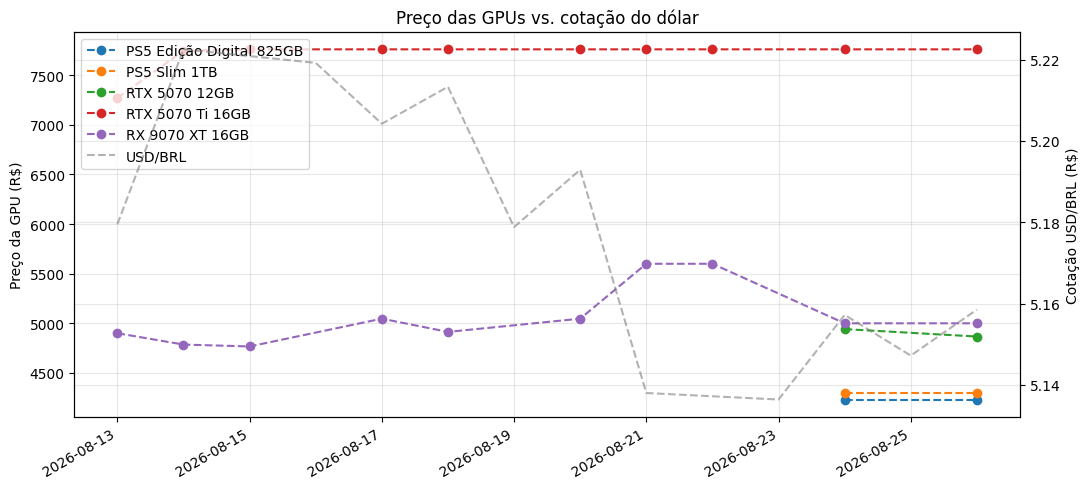

In [9]:
if not CSV_DOLAR.exists():
    print("Ainda não há data/cotacao_dolar.csv — rode a célula da Seção 2 com sucesso primeiro.")
else:
    df_dolar_local = pd.read_csv(CSV_DOLAR, parse_dates=["data"])
    df_dolar_local["data"] = df_dolar_local["data"].dt.date

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()

    for modelo, grupo in df.groupby("modelo"):
        diario = grupo.groupby("data")["preco"].mean().reset_index()
        diario["data_dt"] = pd.to_datetime(diario["data"])
        ax1.plot(diario["data_dt"], diario["preco"], marker="o", linestyle = '--', label=modelo)

    dolar_no_periodo = df_dolar_local[df_dolar_local["data"] >= df["data"].min()]
    ax2.plot(pd.to_datetime(dolar_no_periodo["data"]), dolar_no_periodo["cotacao_venda"],
              color="gray", linestyle="--", alpha=0.6, label="USD/BRL")

    ax1.set_ylabel("Preço da GPU (R$)")
    ax2.set_ylabel("Cotação USD/BRL (R$)")
    ax1.set_title("Preço das GPUs vs. cotação do dólar")
    fig.autofmt_xdate()

    linhas1, labels1 = ax1.get_legend_handles_labels()
    linhas2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(linhas1 + linhas2, labels1 + labels2, loc="upper left")
    plt.tight_layout()
    plt.show()


## 9. Sinal de possível bom momento de compra

Compara o preço mais recente de cada modelo com a média móvel — quando o preço atual está bem abaixo da média recente, pode ser um indício de boa oportunidade. **Isso é só um indicador estatístico simples, não uma recomendação financeira.**

In [10]:
LIMIAR_ALERTA_PCT = 5  # considerar "abaixo da média" a partir de X%

for modelo, grupo in df.groupby("modelo"):
    diario_medio = grupo.groupby("data")["preco"].mean().reset_index()
    diario_minimo = grupo.groupby("data")["preco"].min().reset_index()

    if len(diario_medio) < 3:
        print(f"{modelo}: poucos pontos ainda ({len(diario_medio)}) para calcular um sinal confiável.\n")
        continue

    media_movel = diario_medio["preco"].rolling(min(JANELA_MEDIA_MOVEL, len(diario_medio)), min_periods=1).mean().iloc[-1]
    preco_atual = diario_minimo["preco"].iloc[-1]
    variacao_pct = (preco_atual - media_movel) / media_movel * 100

    sinal = "📉 possível bom momento" if variacao_pct <= -LIMIAR_ALERTA_PCT else (
        "📈 acima da média recente" if variacao_pct >= LIMIAR_ALERTA_PCT else "➡️ dentro da média recente"
    )

    print(f"{modelo}")
    print(f"  Menor preço atual: R$ {preco_atual:,.2f}")
    print(f"  Média móvel recente: R$ {media_movel:,.2f}")
    print(f"  Variação: {variacao_pct:+.1f}%  →  {sinal}\n")


PS5 Edição Digital 825GB: poucos pontos ainda (2) para calcular um sinal confiável.

PS5 Slim 1TB: poucos pontos ainda (2) para calcular um sinal confiável.

RTX 5070 12GB: poucos pontos ainda (2) para calcular um sinal confiável.

RTX 5070 Ti 16GB
  Menor preço atual: R$ 7,083.08
  Média móvel recente: R$ 7,760.97
  Variação: -8.7%  →  📉 possível bom momento

RX 9070 XT 16GB
  Menor preço atual: R$ 4,899.89
  Média móvel recente: R$ 5,172.33
  Variação: -5.3%  →  📉 possível bom momento



## 10. Variação do dólar no período de coleta

Resume quanto o USD/BRL andou entre o primeiro e o último dia cobertos pelo seu histórico de preços (não os 365 dias completos da Seção 2, só o recorte que se sobrepõe à sua coleta).

Período de coleta: 2026-08-13 a 2026-08-26
Dólar em 2026-08-13: R$ 5.1795
Dólar em 2026-08-26: R$ 5.1585
Variação no período: -0.41%
Mínima: R$ 5.1364  |  Máxima: R$ 5.2225


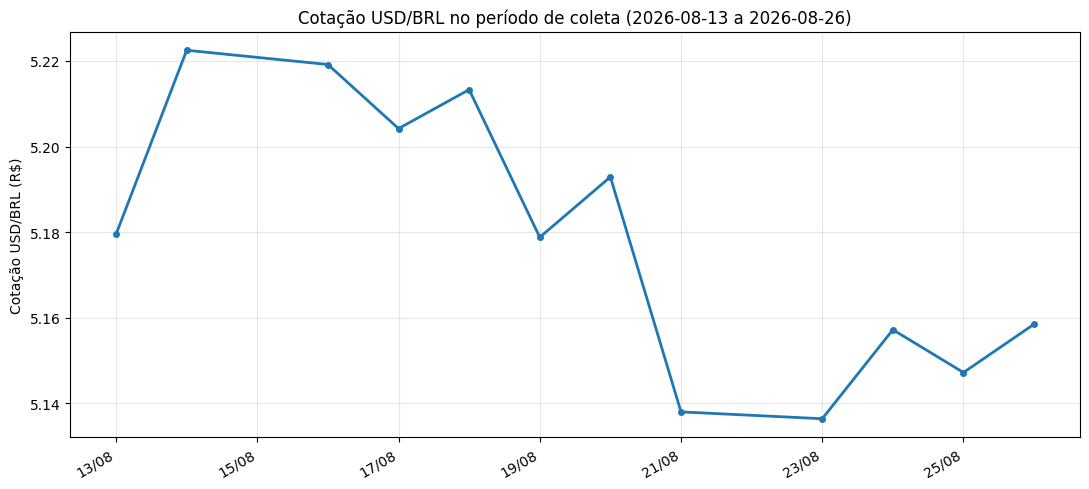

In [11]:
if not CSV_DOLAR.exists():
    print("Ainda não há data/cotacao_dolar.csv — rode a célula da Seção 2 com sucesso primeiro.")
else:
    df_dolar_periodo = pd.read_csv(CSV_DOLAR, parse_dates=["data"])
    df_dolar_periodo["data"] = df_dolar_periodo["data"].dt.date

    inicio, fim = df["data"].min(), df["data"].max()
    df_dolar_periodo = df_dolar_periodo[
        (df_dolar_periodo["data"] >= inicio) & (df_dolar_periodo["data"] <= fim)
    ].sort_values("data")

    if len(df_dolar_periodo) < 2:
        print(
            f"Só há {len(df_dolar_periodo)} cotação(ões) do dólar no período coletado "
            f"({inicio} a {fim}) — sem pontos suficientes para calcular variação."
        )
    else:
        cotacao_inicial = df_dolar_periodo["cotacao_venda"].iloc[0]
        cotacao_final = df_dolar_periodo["cotacao_venda"].iloc[-1]
        cotacao_minima = df_dolar_periodo["cotacao_venda"].min()
        cotacao_maxima = df_dolar_periodo["cotacao_venda"].max()
        variacao_pct = (cotacao_final - cotacao_inicial) / cotacao_inicial * 100

        print(f"Período de coleta: {inicio} a {fim}")
        print(f"Dólar em {inicio}: R$ {cotacao_inicial:,.4f}")
        print(f"Dólar em {fim}: R$ {cotacao_final:,.4f}")
        print(f"Variação no período: {variacao_pct:+.2f}%")
        print(f"Mínima: R$ {cotacao_minima:,.4f}  |  Máxima: R$ {cotacao_maxima:,.4f}")

        fig, ax = plt.subplots()
        ax.plot(
            pd.to_datetime(df_dolar_periodo["data"]), df_dolar_periodo["cotacao_venda"],
            color="tab:blue", linewidth=2, marker="o", markersize=4,
        )
        ax.set_title(f"Cotação USD/BRL no período de coleta ({inicio} a {fim})")
        ax.set_ylabel("Cotação USD/BRL (R$)")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()


## 11. Histórico completo do dólar (interativo)

Mesma ideia da Seção 10, mas sem recortar pelo período de coleta — usa todas as cotações que existem em `data/cotacao_dolar.csv` (até ~365 dias, dependendo de quando a Seção 2 foi rodada pela última vez). O gráfico aqui é interativo (Plotly): passe o mouse sobre a linha para ver a data e a cotação exata daquele ponto.

In [13]:
if not CSV_DOLAR.exists():
    print("Ainda não há data/cotacao_dolar.csv — rode a célula da Seção 2 com sucesso primeiro.")
else:
    df_dolar_completo = pd.read_csv(CSV_DOLAR, parse_dates=["data"]).sort_values("data")

    inicio, fim = df_dolar_completo["data"].min(), df_dolar_completo["data"].max()
    cotacao_inicial = df_dolar_completo["cotacao_venda"].iloc[0]
    cotacao_final = df_dolar_completo["cotacao_venda"].iloc[-1]
    cotacao_minima = df_dolar_completo["cotacao_venda"].min()
    cotacao_maxima = df_dolar_completo["cotacao_venda"].max()
    variacao_pct = (cotacao_final - cotacao_inicial) / cotacao_inicial * 100

    print(f"Período completo: {inicio.date()} a {fim.date()} ({len(df_dolar_completo)} cotações)")
    print(f"Dólar em {inicio.date()}: R$ {cotacao_inicial:,.4f}")
    print(f"Dólar em {fim.date()}: R$ {cotacao_final:,.4f}")
    print(f"Variação no período completo: {variacao_pct:+.2f}%")
    print(f"Mínima: R$ {cotacao_minima:,.4f}  |  Máxima: R$ {cotacao_maxima:,.4f}")

    fig = go.Figure(
        go.Scatter(
            x=df_dolar_completo["data"],
            y=df_dolar_completo["cotacao_venda"],
            mode="lines",
            line=dict(color="#1f77b4", width=2),
            hovertemplate="%{x|%d/%m/%Y}<br>R$ %{y:.4f}<extra></extra>",
        )
    )
    fig.update_layout(
        title=f"Cotação USD/BRL — histórico completo ({inicio.date()} a {fim.date()})",
        yaxis_title="Cotação USD/BRL (R$)",
        template="plotly_white",
        hovermode="x unified",
        height=500,
    )
    fig.show()


Período completo: 2025-07-06 a 2026-08-26 (360 cotações)
Dólar em 2025-07-06: R$ 5.4174
Dólar em 2026-08-26: R$ 5.1585
Variação no período completo: -4.78%
Mínima: R$ 4.9064  |  Máxima: R$ 5.5987


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [14]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [15]:
data_inicio = df_dolar_completo['data'].min()
data_fim = df_dolar_completo['data'].max()
dias_transcorridos = (data_fim - data_inicio).days
media_periodo = df_dolar_completo['cotacao_venda'].mean()
valor_hoje = df_dolar_completo['cotacao_venda'].iloc[-1]
valor_ontem = df_dolar_completo['cotacao_venda'].iloc[-2]
ultimos_5_dias = df_dolar_completo.tail(5)

tabela_cotacao = pd.DataFrame(
    {
'Hoje': valor_hoje,
'Var % anterior': ((valor_hoje - valor_ontem)/valor_ontem)*100,
'Var % ultimos 5 dias': ((valor_hoje - ultimos_5_dias['cotacao_venda'].mean())/ultimos_5_dias['cotacao_venda'].mean())*100,
"Media ult 5 d": ultimos_5_dias['cotacao_venda'].mean(),
'Var % periodo': ((valor_hoje - media_periodo)/media_periodo)*100,
'Média período analisado': media_periodo,
'Desvio padrão': [df_dolar_completo['cotacao_venda'].std()],
'Inicio obso': data_inicio,
'ultimo dia obs': data_fim,
'Dias transc': dias_transcorridos
}
)


colunas_numericas = tabela_cotacao.select_dtypes("number").columns
tabela_cotacao[colunas_numericas] = tabela_cotacao[colunas_numericas].round(3)
display(tabela_cotacao)


,Hoje,Var % anterior,Var % ultimos 5 dias,Media ult 5 d,Var % periodo,Média período analisado,Desvio padrão,Inicio obso,ultimo dia obs,Dias transc
0,5.158,0.22,0.214,5.147,-2.065,5.267,0.171,2025-07-06,2026-08-26,416


## Solução de problemas

**Um scraper não retornou preço nenhum:**
O site provavelmente mudou o layout. Rode a coleta com `debug=True` (já é o
padrão na célula da Seção 1) — isso salva o HTML bruto em
`data/debug_html/`. Abra o arquivo, procure o preço no código-fonte e ajuste
a função `_extrair_via_jsonld`/`_extrair_via_regex` (Kabum, Terabyte),
`_extrair_via_busca_promotech` (Promotech) ou `_extrair_via_jsonld_buscape`
(Buscapé/PS5) em `scrapers.py`.

**Quero adicionar outra loja ou trocar a SKU de um produto:**
Edite o dicionário `PRODUTOS_MODELOS` em `config.py`. Para uma loja com
página de produto própria (como Kabum/Terabyte), adicione uma chave
`<loja>_url` e inclua essa chave em `LOJAS_ATIVAS` (scrapers.py) — o
scraper genérico (`coletar_preco`, JSON-LD + fallback por regex) deve
funcionar sem mudanças. Para um comparador de preços com página de busca
(como o Promotech), é melhor seguir o padrão
`promotech_busca_url`/`promotech_busca_termo` e uma função dedicada, já que
é preciso achar o card certo entre vários resultados antes de extrair o
preço. Para um comparador cuja própria página de produto já expõe o preço
agregado em JSON-LD (como o Buscapé), basta uma chave `buscape_url` — ver
`coletar_preco_buscape`.

**Quero automatizar a coleta (sem rodar o notebook manualmente todo dia):**
No Windows, o Agendador de Tarefas pode rodar
`jupyter nbconvert --to notebook --execute analise_precos.ipynb --output analise_precos.ipynb`
uma vez por dia. No Linux/Mac, o mesmo comando funciona via `cron`.

**Sobre confiabilidade dos scrapers:**
Kabum e Terabyte tendem a manter dados estruturados (JSON-LD) nas páginas de
produto, o que ajuda a manter o scraper estável mesmo com pequenas mudanças
visuais no site. O Buscapé também usa JSON-LD (offers.lowPrice), mesma
lógica. Ainda assim, nenhum scraper é permanente — trate ajustes ocasionais
como parte normal da manutenção da ferramenta.

**Por que a Pichau não está na lista de lojas?**
O site responde com um desafio Cloudflare (HTTP 403, "Just a moment...")
para requisições automatizadas — não é um problema de seletor CSS ou de
link quebrado, é bloqueio deliberado de bots. Contornar isso de forma
confiável exigiria automatizar um navegador para resolver o desafio, o que
fere os termos de uso do site, então optamos por deixar a Pichau de fora da
coleta ativa.
